In [30]:
import pandas as pd

In [69]:
df=pd.read_csv('train_df.csv',index_col=0)
df

,text,claim_labels
0,"Of course, we have to improve the system, but ...","[200, 230]"
1,I think this is partly what's been going wrong...,"[200, 230]"
2,Or you could actually take the view that I'm n...,[]
3,But then you'll ignore the result. No.,[]
4,No. I want to be a member of the European Unio...,"[1900, 1910]"
...,...,...
2864,"Well, of course, as I've already outlined, as ...","[1200, 1202, 1209]"
2865,"What I would say is, for example, the Dome was...","[100, 105, 200, 201]"
2866,"Terry, like so many people around the country,...","[100, 107, 300, 325]"
2867,"Yeah, I was incredibly sad to have caused peop...","[1600, 1609]"


In [84]:
df_val = df.copy()
df_val['claim_labels'] = df_val['claim_labels'].fillna('')

df_val_temp = df_val.copy()
def clean_labels(x):
    if pd.isna(x) or x == "":
        return []
    if isinstance(x, str):
        try:
            splits = x.split(',')
            if 'None' in x:
                return []
            elif '' in splits:                
                splits.remove('')
            elif ' ' in splits:                
                splits.remove(' ')
#             elif x[-1]
            return [int(i.strip()) for i in splits]
        except:
            print(x)
            print(splits)
    return x

df_val_temp['claim_labels'] = df_val_temp['claim_labels'].apply(clean_labels)

df_human = df_val_temp.copy()
df_human

[200, 230]
['[200', ' 230]']
[200, 230]
['[200', ' 230]']
[]
['[]']
[]
['[]']
[1900, 1910]
['[1900', ' 1910]']
[100, 107]
['[100', ' 107]']
[]
['[]']
[]
['[]']
[]
['[]']
[1900]
['[1900]']
[]
['[]']
[200, 230, 1900]
['[200', ' 230', ' 1900]']
[]
['[]']
[]
['[]']
[1900, 1920]
['[1900', ' 1920]']
[]
['[]']
[]
['[]']
[]
['[]']
[100, 107, 200, 230]
['[100', ' 107', ' 200', ' 230]']
[]
['[]']
[100, 107]
['[100', ' 107]']
[]
['[]']
[1900, 1910]
['[1900', ' 1910]']
[]
['[]']
[]
['[]']
[]
['[]']
[]
['[]']
[100, 107]
['[100', ' 107]']
[]
['[]']
[200, 230]
['[200', ' 230]']
[]
['[]']
[]
['[]']
[100, 107, 200]
['[100', ' 107', ' 200]']
[]
['[]']
[1900, 1910]
['[1900', ' 1910]']
[]
['[]']
[]
['[]']
[600, 601]
['[600', ' 601]']
[1900, 1910]
['[1900', ' 1910]']
[]
['[]']
[]
['[]']
[1900, 1920]
['[1900', ' 1920]']
[1900, 1920]
['[1900', ' 1920]']
[200, 230]
['[200', ' 230]']
[200, 230]
['[200', ' 230]']
[]
['[]']
[600, 601]
['[600', ' 601]']
[]
['[]']
[]
['[]']
[200, 230]
['[200', ' 230]']
[]
['[]']
[

,text,claim_labels
0,"Of course, we have to improve the system, but ...","[200, 230]"
1,I think this is partly what's been going wrong...,"[200, 230]"
2,Or you could actually take the view that I'm n...,[]
3,But then you'll ignore the result. No.,[]
4,No. I want to be a member of the European Unio...,"[1900, 1910]"
...,...,...
2864,"Well, of course, as I've already outlined, as ...","[1200, 1202, 1209]"
2865,"What I would say is, for example, the Dome was...","[100, 105, 200, 201]"
2866,"Terry, like so many people around the country,...","[100, 107, 300, 325]"
2867,"Yeah, I was incredibly sad to have caused peop...","[1600, 1609]"


In [85]:
df=df_human

In [76]:
def get_label_info(code):
    name = titles.get(code, "Unknown")
    is_supertopic = (code % 100 == 0)
    return pd.Series([name, is_supertopic])

df_exploded = df.explode('claim_labels')
df_exploded = df_exploded.dropna(subset=['claim_labels'])


df_exploded[['topic_name', 'is_supertopic']] = df_exploded['claim_labels'].apply(get_label_info)


total_samples = len(df)
empty_labels = df['claim_labels'].apply(len).eq(0).sum()
avg_labels = df['claim_labels'].apply(len).mean()

print(f"Total rows: {total_samples}")
print(f"Rows with no labels: {empty_labels} ({100*empty_labels/total_samples:.1f}%)")
print(f"Average labels per text: {avg_labels:.2f}")


top_topics = df_exploded['topic_name'].value_counts().head(10)

TypeError: not all arguments converted during string formatting

In [3]:
df_val=pd.read_csv('labelling_validation.csv', index_col=0)
df_val['Claim_Labels'] = df_val['Claim_Labels'].fillna('')
df_val.rename(columns={'Claim_Labels': 'claim_labels'}, inplace=True)

df_val_temp = df_val.copy()
def clean_labels(x):
    if pd.isna(x) or x == "":
        return []
    if isinstance(x, str):
        try:
            splits = x.split(',')
            if 'None' in x:
                return []
            elif '' in splits:                
                splits.remove('')
            elif ' ' in splits:                
                splits.remove(' ')
#             elif x[-1]
            return [int(i.strip()) for i in splits]
        except:
            print(x)
            print(splits)
    return x

df_val_temp['claim_labels'] = df_val_temp['claim_labels'].apply(clean_labels)

df_val_temp.rename(columns={'ID': 'id'}, inplace=True)
df_human = df_val_temp.copy()
df_human

,id,Text,claim_labels
0,0,"So knife crime's going to go up, because the e...","[1200, 1211]"
1,1,Of course Gordon Brown's right to say there's ...,"[100, 107, 1300, 1302, 600, 602, 603, 1200, 1208]"
2,2,"You won't admit the truth, will you? The truth...",[]
3,3,"I tell you how we pay for it. We would, for in...","[100, 107]"
4,4,"You just, look, there's no point in speculatin...",[]
...,...,...,...
364,1426,I think the lady makes a very important point....,"[100, 103, 1200, 1207, 1900, 1910, 500, 506]"
365,1756,I've met some of the people who have rightly c...,"[1200, 1207]"
366,2601,"Well, I share the frustration of both our ques...","[1900, 1910, 400, 406, 200, 202, 230]"
367,3070,You're saying people voted for 10% tariffs on ...,"[1000, 1006]"


In [4]:
df = df_human

In [6]:
titles = {
    100: "Macroeconomics",
    101: "Inflation, prices, and interest rates",
    103: "Unemployment rate",
    104: "Monetary Supply, Central Bank, and the Treasury",
    105: "National Budget, Debt, public spending",
    107: "Taxation, Tax policy, and Tax Reform",
    108: "Industrial Policy, Privatisation, Nationalisation",
    200: "Civil Rights",
    201: "Ethnic Minority and Racial Group Discrimination",
    202: "Gender and Sexual Orientation Discrimination",
    207: "Freedom of Speech & Religion",
    208: "Right to Privacy and Access to Government Information",
    230: "Immigration",
    300: "Health",
    301: "Health Care Reform",
    321: "Regulation of Drug Industry, Medical Devices, and Clinical Labs",
    325: "Health Manpower and Training",
    331: "Prevention, Communicable Diseases and Health Promotion",
    332: "Infants and Children",
    334: "Long-Term Care, Home Health, and Rehabilitation",
    344: "Drug and Alcohol or Substance Abuse Treatment",
    400: "Agriculture",
    401: "Agricultural Trade",
    406: "Animal Welfare",
    408: "Fisheries and Fishing",
    500: "Labour and Employment",
    502: "Employment Training and Workforce Development",
    503: "Employee Benefits",
    504: "Employee Relations and Labour Unions",
    505: "Fair Labour Standards",
    506: "Youth Employment and Child Labour",
    508: "Parental Leave and Child Care",
    529: "Migrant and Seasonal Workers",
    600: "Education",
    601: "Higher Education",
    602: "Elementary and Secondary Education",
    603: "Education of Underprivileged Students",
    604: "Vocational Education",
    606: "Special Education",
    700: "Environment",
    701: "Water Pollution",
    703: "Waste Disposal",
    705: "Air Pollution, Global Warming, and Noise Pollution",
    709: "Species and Forest Protection",
    800: "Energy",
    801: "Nuclear Energy and Nuclear Regulatory Issues",
    803: "Natural Gas and Oil",
    805: "Coal",
    806: "Alternative and Renewable Energy",
    807: "Energy Conservation",
    1000: "Transportation",
    1001: "Mass and Public Transportation and Safety",
    1002: "Highway (Road) Construction, Maintenance, and Safety",
    1003: "Airports, Airlines, Air Traffic Control and Safety",
    1005: "Railroad Transportation and Safety",
    1006: "Truck and Automobile Transportation and Safety",
    1200: "Law, Crime, and Family Issues",
    1202: "White Collar Crime and Organized Crime",
    1203: "Illegal Drug Production, Trafficking, and Control",
    1205: "Prison System",
    1206: "Juvenile Crime and the Juvenile Justice System",
    1207: "Child Abuse",
    1208: "Family Issues",
    1209: "Police, Fire, and Weapons Control",
    1211: "Riots and Crime Prevention",
    1300: "Social Welfare",
    1302: "Poverty and Assistance for Low-Income Families",
    1303: "Elderly Issues and Elderly Assistance Programs, State Pensions",
    1304: "Assistance to the Disabled and Handicapped",
    1305: "Social Services and Volunteer Associations",
    1400: "Planning and Housing Issues",
    1401: "Housing and Community Development",
    1406: "Low and Middle Income Housing Programs and Needs",
    1407: "Veterans Housing Assistance and Military Housing Programs",
    1409: "Housing Assistance for Homeless and Homeless Issues",
    1410: "Mortgages",
    1500: "Finance and Domestic Commerce",
    1501: "Banking System and Financial Institution Regulation",
    1521: "Small Business Issues",
    1524: "Tourism",
    1600: "Defence",
    1603: "Military Intelligence, Intelligence Services, Espionage",
    1608: "Manpower, Military Personnel and Dependents",
    1609: "Veterans Issues",
    1610: "Military Procurement and Weapons System Acquisitions and Evaluation",
    1627: "Domestic and International Terrorism",
    1800: "Foreign Trade",
    1803: "Export Promotion and Regulation, Export Credit Agencies",
    1806: "Productivity and Competitiveness of U.K. Business, U.K. Balance of Payments",
    1900: "International Affairs",
    1901: "Foreign Aid",
    1907: "China",
    1909: "Eastern Europe",
    1910: "Western Europe, Common Market Issues",
    1911: "Africa",
    1920: "Middle East",
    1926: "International Organizations other than Finance",
    1930: "North America and North Atlantic Ocean",
    2000: "Government Operations",
    2001: "Intergovernmental Relations",
    2011: "Executive-Legislative Relations and Parliamentary Operations",
    2012: "Political Parties, Campaigns, and Voter Registration",
    2032: "Prime Ministerial or Ministerial Scandals and Resignations"
}

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_label_info(code):
    name = titles.get(code, "Unknown")
    is_supertopic = (code % 100 == 0)
    return pd.Series([name, is_supertopic])

df_exploded = df.explode('claim_labels')
df_exploded = df_exploded.dropna(subset=['claim_labels'])


df_exploded[['topic_name', 'is_supertopic']] = df_exploded['claim_labels'].apply(get_label_info)


total_samples = len(df)
empty_labels = df['claim_labels'].apply(len).eq(0).sum()
avg_labels = df['claim_labels'].apply(len).mean()

print(f"Total rows: {total_samples}")
print(f"Rows with no labels: {empty_labels} ({100*empty_labels/total_samples:.1f}%)")
print(f"Average labels per text: {avg_labels:.2f}")


top_topics = df_exploded['topic_name'].value_counts().head(10)

Total rows: 369
Rows with no labels: 66 (17.9%)
Average labels per text: 2.76


In [83]:
df

,text,claim_labels
0,"Of course, we have to improve the system, but ...","[200, 230]"
1,I think this is partly what's been going wrong...,"[200, 230]"
2,Or you could actually take the view that I'm n...,[]
3,But then you'll ignore the result. No.,[]
4,No. I want to be a member of the European Unio...,"[1900, 1910]"
...,...,...
2864,"Well, of course, as I've already outlined, as ...","[1200, 1202, 1209]"
2865,"What I would say is, for example, the Dome was...","[100, 105, 200, 201]"
2866,"Terry, like so many people around the country,...","[100, 107, 300, 325]"
2867,"Yeah, I was incredibly sad to have caused peop...","[1600, 1609]"


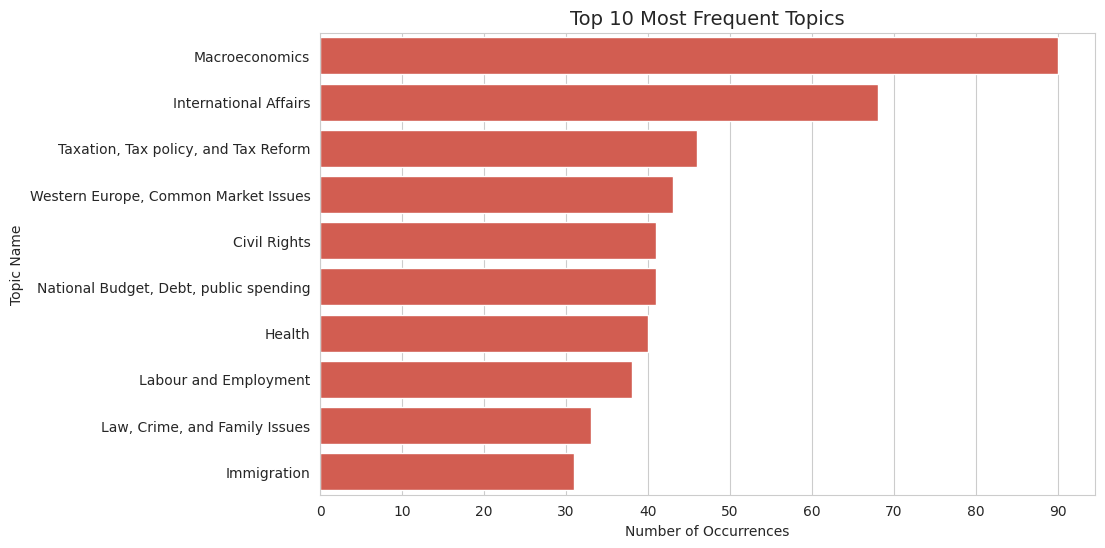

In [19]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax =sns.barplot(x=top_topics.values, y=top_topics.index, color='#e74c3c')
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.title('Top 10 Most Frequent Topics', family='sans-serif', fontsize=14)
plt.xlabel('Number of Occurrences')
plt.ylabel('Topic Name')
plt.show()

In [18]:
import matplotlib.ticker as ticker

In [16]:
df_exploded['topic_name'].value_counts().head(10)

topic_name
Macroeconomics                            90
International Affairs                     68
Taxation, Tax policy, and Tax Reform      46
Western Europe, Common Market Issues      43
Civil Rights                              41
National Budget, Debt, public spending    41
Health                                    40
Labour and Employment                     38
Law, Crime, and Family Issues             33
Immigration                               31
Name: count, dtype: int64

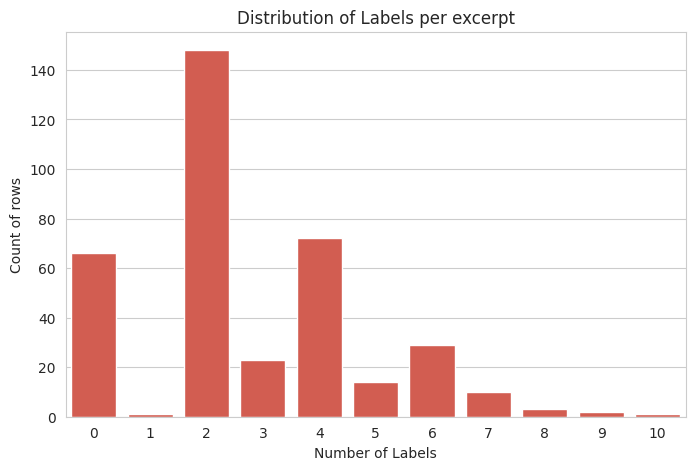

In [12]:
label_counts = df['claim_labels'].apply(len)
plt.figure(figsize=(8, 5))
sns.countplot(x=label_counts, color='#e74c3c')
plt.title('Distribution of Labels per excerpt', family='sans-serif')
plt.xlabel('Number of Labels')
plt.ylabel('Count of rows')
plt.show()

In [15]:
hierarchy_summary = df_exploded.groupby('is_supertopic').size()
print("Label occurrences by Type:")
print(f"Supertopics (Multiples of 100): {hierarchy_summary.get(True, 0)}")
print(f"Subtopics: {hierarchy_summary.get(False, 0)}")

Label occurrences by Type:
Supertopics (Multiples of 100): 480
Subtopics: 540


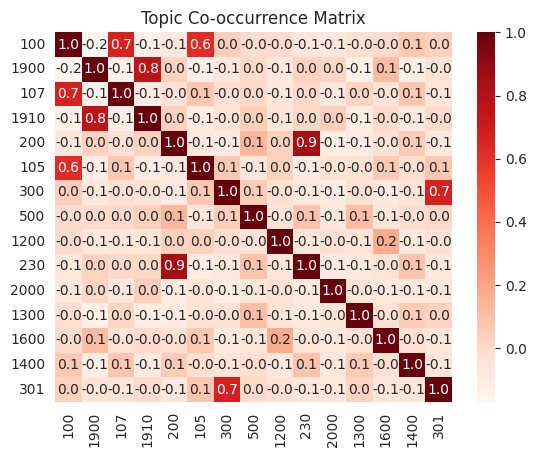

In [29]:
from sklearn.preprocessing import MultiLabelBinarizer

# Binarize the labels (converts lists to a 0/1 matrix)
mlb = MultiLabelBinarizer()
binary_matrix = mlb.fit_transform(df['claim_labels'])
df_binary = pd.DataFrame(binary_matrix, columns=mlb.classes_)

# Compute the correlation (co-occurrence)
# Filter for only top 15 codes to keep it readable
top_codes = df_exploded['claim_labels'].value_counts().head(15).index
df_binary[top_codes] = df_binary[top_codes].apply(lambda x: round(x, 1))
co_occurrence = df_binary[top_codes].corr()

sns.heatmap(co_occurrence, annot=True, cmap='Reds', fmt='.1f')
plt.title("Topic Co-occurrence Matrix")
plt.show()

In [31]:
llm_df = pd.read_csv('llm_per_label_performance.csv')
llm_df

,code,precision,recall,f1-score,support
0,samples avg,0.472116,0.508562,0.470239,1019.0
1,weighted avg,0.589953,0.559372,0.533915,1019.0
2,macro avg,0.362536,0.322909,0.302198,1019.0
3,micro avg,0.521978,0.559372,0.540028,1019.0
4,100,0.568345,0.877778,0.689956,90.0
...,...,...,...,...,...
103,801,0.000000,0.000000,0.000000,1.0
104,1501,0.000000,0.000000,0.000000,1.0
105,1524,0.000000,0.000000,0.000000,1.0
106,1907,0.000000,0.000000,0.000000,1.0


In [32]:
df = llm_df.copy()

In [33]:
plot_df = df[~df['code'].str.contains('avg', na=False)].copy()

cols = ['precision', 'recall', 'f1-score', 'support']
plot_df[cols] = plot_df[cols].apply(pd.to_numeric)

plot_df['type'] = plot_df['code'].apply(lambda x: 'Super' if int(x) % 100 == 0 else 'Sub')

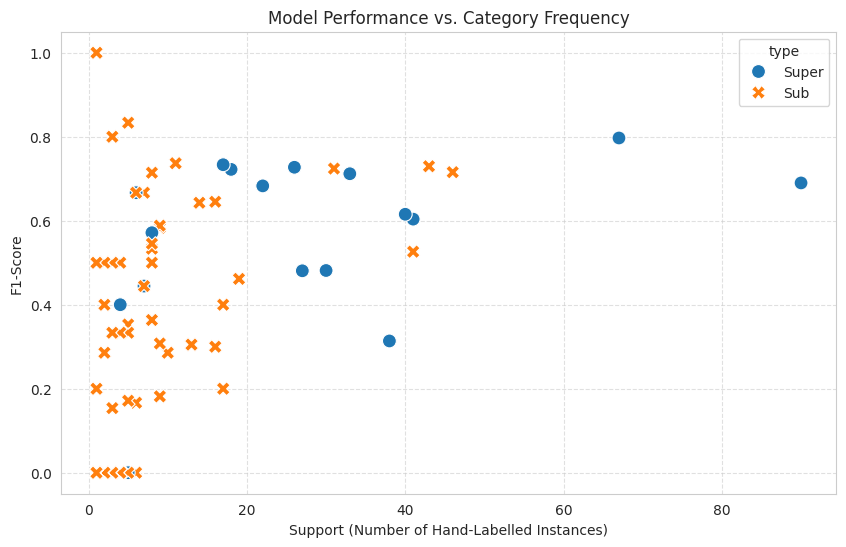

In [39]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='support', y='f1-score', hue='type', style='type', s=100)

plt.title('Model Performance vs. Category Frequency')
plt.xlabel('Support (Number of Hand-Labelled Instances)')
plt.ylabel('F1-Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [40]:
codes_df = df[~df['code'].str.contains('avg', case=False)].copy()

cols = ['precision', 'recall', 'f1-score', 'support']
codes_df[cols] = codes_df[cols].apply(pd.to_numeric)

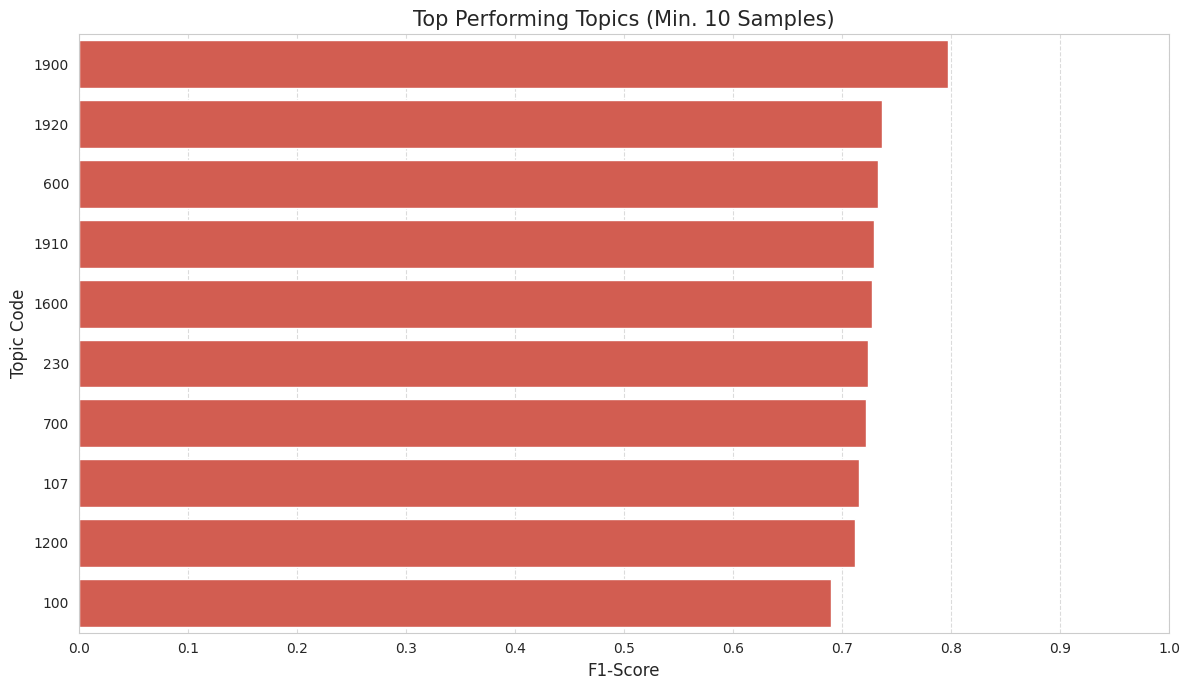

In [49]:
plot_df = df[~df['code'].str.contains('avg', case=False)].copy()
plot_df[['f1-score', 'support']] = plot_df[['f1-score', 'support']].apply(pd.to_numeric)

reliable_df = plot_df[plot_df['support'] >= 10].copy()

reliable_df = reliable_df.sort_values(by='f1-score', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=reliable_df.head(10), 
    y='code', 
    color='#e74c3c'
)

plt.title('Top Performing Topics (Min. 10 Samples)', fontsize=15)
plt.xlabel('F1-Score', fontsize=12)
plt.ylabel('Topic Code', fontsize=12)
plt.xlim(0, 1)

plt.xticks(np.arange(0, 1.1, 0.1))
plt.grid(axis='x', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

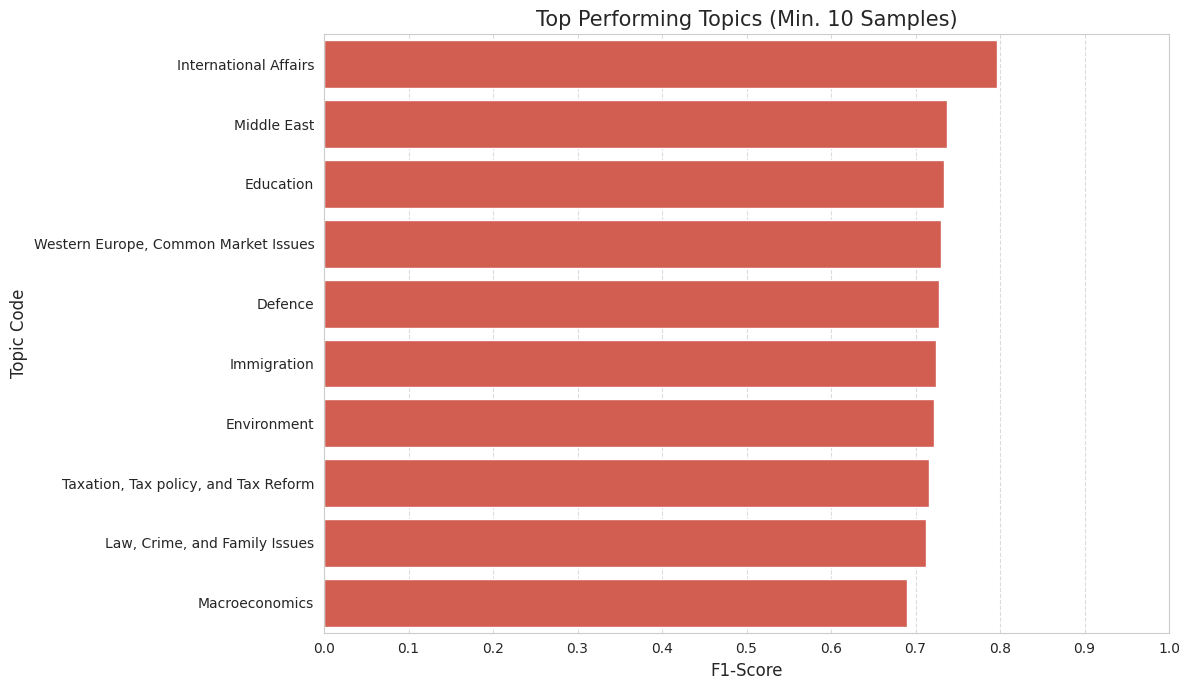

In [54]:
plot_df = df[~df['code'].str.contains('avg', case=False)].copy()
plot_df[['f1-score', 'support']] = plot_df[['f1-score', 'support']].apply(pd.to_numeric)

reliable_df = plot_df[plot_df['support'] >= 10].copy()

reliable_df = reliable_df.sort_values(by='f1-score', ascending=False)
def matcher(code):
    return titles[int(code)]
reliable_df['topic_name'] = reliable_df['code'].apply(matcher)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=reliable_df.head(10), # Showing the top 15 for readability
    x='f1-score', 
    y='topic_name', 
    color='#e74c3c'
)

plt.title('Top Performing Topics (Min. 10 Samples)', fontsize=15)
plt.xlabel('F1-Score', fontsize=12)
plt.ylabel('Topic Code', fontsize=12)
plt.xlim(0, 1)

plt.xticks(np.arange(0, 1.1, 0.1))
plt.grid(axis='x', linestyle='--', alpha=0.7)



plt.tight_layout()
plt.show()

In [88]:
df=pd.read_csv('train_df.csv',index_col=0)
df

,text,claim_labels
0,"Of course, we have to improve the system, but ...","[200, 230]"
1,I think this is partly what's been going wrong...,"[200, 230]"
2,Or you could actually take the view that I'm n...,[]
3,But then you'll ignore the result. No.,[]
4,No. I want to be a member of the European Unio...,"[1900, 1910]"
...,...,...
2864,"Well, of course, as I've already outlined, as ...","[1200, 1202, 1209]"
2865,"What I would say is, for example, the Dome was...","[100, 105, 200, 201]"
2866,"Terry, like so many people around the country,...","[100, 107, 300, 325]"
2867,"Yeah, I was incredibly sad to have caused peop...","[1600, 1609]"


In [57]:

def clean_labels(x):
    if pd.isna(x) or x == "" or x == "[]":
        return []
    if isinstance(x, str):
        # Handles "100, 107" or "[100, 107]"
        return [int(i.strip()) for i in x.replace('[','').replace(']','').split(',') if i.strip()]
    return x

df['clean_labels'] = df['claim_labels'].apply(clean_labels)


mlb = MultiLabelBinarizer()
label_matrix = pd.DataFrame(
    mlb.fit_transform(df['clean_labels']),
    columns=mlb.classes_,
    index=df.index
)

In [64]:
summary_stats = {
    "Total Excerpts": len(df),
    "Empty (NaN) Rows": (df['label_count'] == 0).sum(),
    "Average Labels/Excerpt": df['label_count'].mean(),
    "Max Labels in one Excerpt": df['label_count'].max(),    
}
print(pd.Series(summary_stats))

Total Excerpts               2869.000000
Empty (NaN) Rows              537.000000
Average Labels/Excerpt          2.760544
Max Labels in one Excerpt      19.000000
dtype: float64


In [63]:
df.loc[df['label_count']==19]

,text,claim_labels,clean_labels,label_count
1680,"Robert, earlier in my career I worked in North...","[100, 101, 103, 105, 1200, 1202, 1205, 1206, 1...","[100, 101, 103, 105, 1200, 1202, 1205, 1206, 1...",19


In [87]:
df

,text,claim_labels
0,"Of course, we have to improve the system, but ...","[200, 230]"
1,I think this is partly what's been going wrong...,"[200, 230]"
2,Or you could actually take the view that I'm n...,[]
3,But then you'll ignore the result. No.,[]
4,No. I want to be a member of the European Unio...,"[1900, 1910]"
...,...,...
2864,"Well, of course, as I've already outlined, as ...","[1200, 1202, 1209]"
2865,"What I would say is, for example, the Dome was...","[100, 105, 200, 201]"
2866,"Terry, like so many people around the country,...","[100, 107, 300, 325]"
2867,"Yeah, I was incredibly sad to have caused peop...","[1600, 1609]"


In [95]:
import ast
# 1. Convert the 'string' representation of a list into an actual Python list
# This turns "[200, 230]" (string) into [200, 230] (list)
df['claim_labels'] = df['claim_labels'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 2. Now calculate the length - it will correctly count the items
df['num_labels'] = df['claim_labels'].apply(len)

# 3. Proceed with the explode as before
df_exploded = df.explode('claim_labels').dropna(subset=['claim_labels'])

# Check your results
print(df[['claim_labels', 'num_labels']].head())

   claim_labels  num_labels
0    [200, 230]           2
1    [200, 230]           2
2            []           0
3            []           0
4  [1900, 1910]           2


In [103]:
df_exploded = df_exploded.loc[df_exploded['claim_labels'].isin(list(titles.keys()))]

In [104]:
df_exploded

,text,claim_labels,num_labels
0,"Of course, we have to improve the system, but ...",200,2
0,"Of course, we have to improve the system, but ...",230,2
1,I think this is partly what's been going wrong...,200,2
1,I think this is partly what's been going wrong...,230,2
4,No. I want to be a member of the European Unio...,1900,2
...,...,...,...
2867,"Yeah, I was incredibly sad to have caused peop...",1609,2
2868,There are lots of people who go for private he...,100,4
2868,There are lots of people who go for private he...,108,4
2868,There are lots of people who go for private he...,1300,4


In [ ]:
df_exploded['topic_name']=df_exploded['claim_labels'].apply(matcher)
top_10 = df_exploded['topic_name'].value_counts().head(10).reset_index()
top_10.columns = ['Topic Name', 'Count']


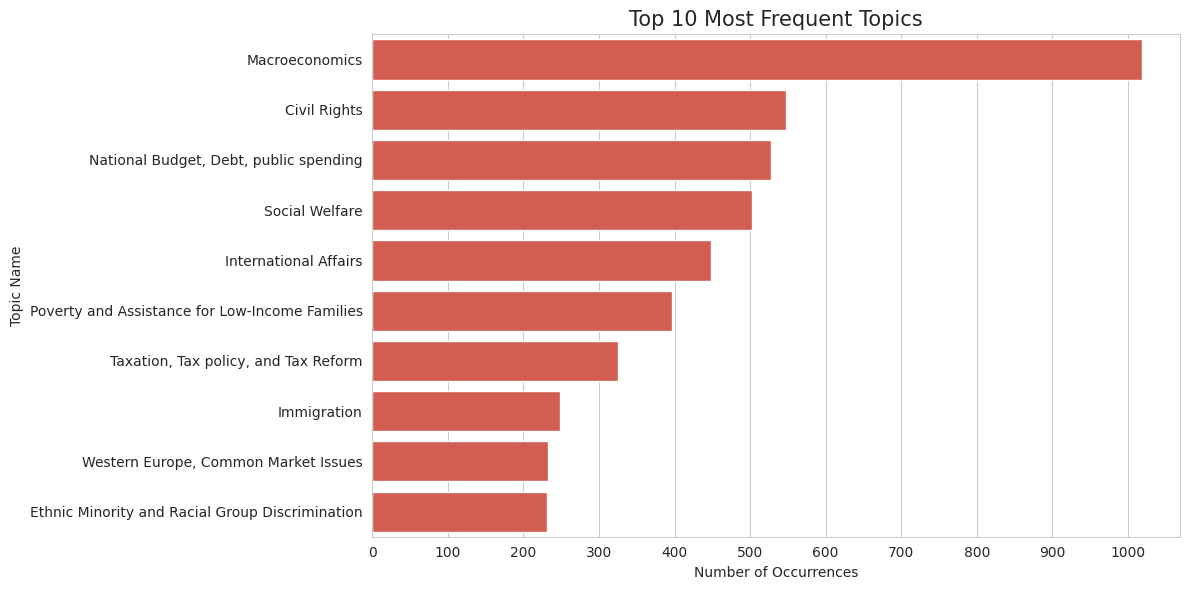

In [107]:

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax=sns.barplot(data=top_10, x='Count', y='Topic Name', color='#e74c3c')
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
plt.title('Top 10 Most Frequent Topics', fontsize=15)
plt.xlabel('Number of Occurrences')
plt.ylabel('Topic Name')
plt.tight_layout()
plt.show()

In [109]:
df

,text,claim_labels,num_labels
0,"Of course, we have to improve the system, but ...","[200, 230]",2
1,I think this is partly what's been going wrong...,"[200, 230]",2
2,Or you could actually take the view that I'm n...,[],0
3,But then you'll ignore the result. No.,[],0
4,No. I want to be a member of the European Unio...,"[1900, 1910]",2
...,...,...,...
2864,"Well, of course, as I've already outlined, as ...","[1200, 1202, 1209]",3
2865,"What I would say is, for example, the Dome was...","[100, 105, 200, 201]",4
2866,"Terry, like so many people around the country,...","[100, 107, 300, 325]",4
2867,"Yeah, I was incredibly sad to have caused peop...","[1600, 1609]",2


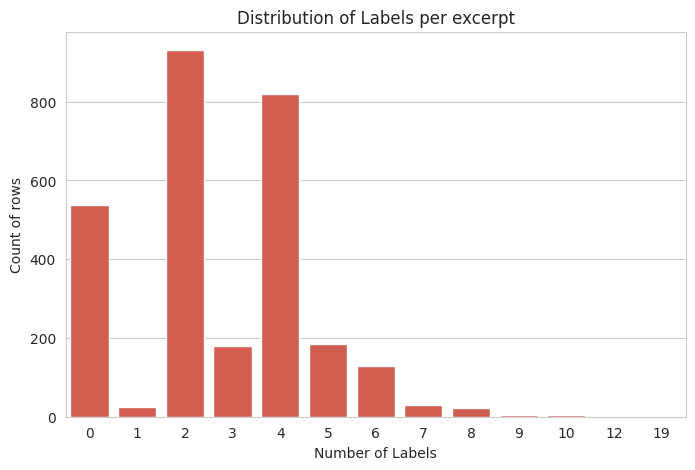

In [111]:
label_counts = df['claim_labels'].apply(len)
plt.figure(figsize=(8, 5))
sns.countplot(x=label_counts, color='#e74c3c')
plt.title('Distribution of Labels per excerpt', family='sans-serif')
plt.xlabel('Number of Labels')
plt.ylabel('Count of rows')
plt.show()

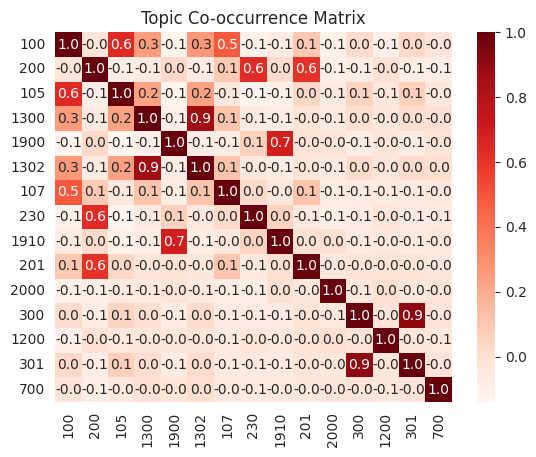

In [112]:
mlb = MultiLabelBinarizer()
binary_matrix = mlb.fit_transform(df['claim_labels'])
df_binary = pd.DataFrame(binary_matrix, columns=mlb.classes_)


top_codes = df_exploded['claim_labels'].value_counts().head(15).index
df_binary[top_codes] = df_binary[top_codes].apply(lambda x: round(x, 1))
co_occurrence = df_binary[top_codes].corr()

sns.heatmap(co_occurrence, annot=True, cmap='Reds', fmt='.1f')
plt.title("Topic Co-occurrence Matrix")
plt.show()